<a href="https://www.kaggle.com/code/shivapipy/agentic-ai-prescription-writer?scriptVersionId=291224315" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### This Project includes usage of the following concepts:
#### 1. Parallel Agents - reaserching and formulating prescription
#### 2. Loop Agents - Refining prescription
#### 3. Sequential Agents - execute the aggregated prescription
#### 4. Building the Workflow - How the Agents pause - take Doctor's input - resume.
#### 5. Agent powered by an LLM - Prescriber Agents powered by gemini-2.5-flash-lite.
#### 6. Built-in tools, such as Google Search - Google search for citations  
#### 7. Observability: Logging, Tracing, Metrics - Tracing Logs.
#### 8. Long Running Operations (Human In The Loop) - Taking Doctor's approval to prescription.
#### 9. Custom tool for confirmation - confirm_prescription for resuming after Doctor's approval


## Problem : Doctors have to spend extra time in writing prescription with hurry as barely one can read prescription for the patient.

## Solution : Agent would write an accurate authentic prescription which then gets approved by doctor and finally gets printed which patients can read and understand easily saving doctors time devoting the saved time for next patients.


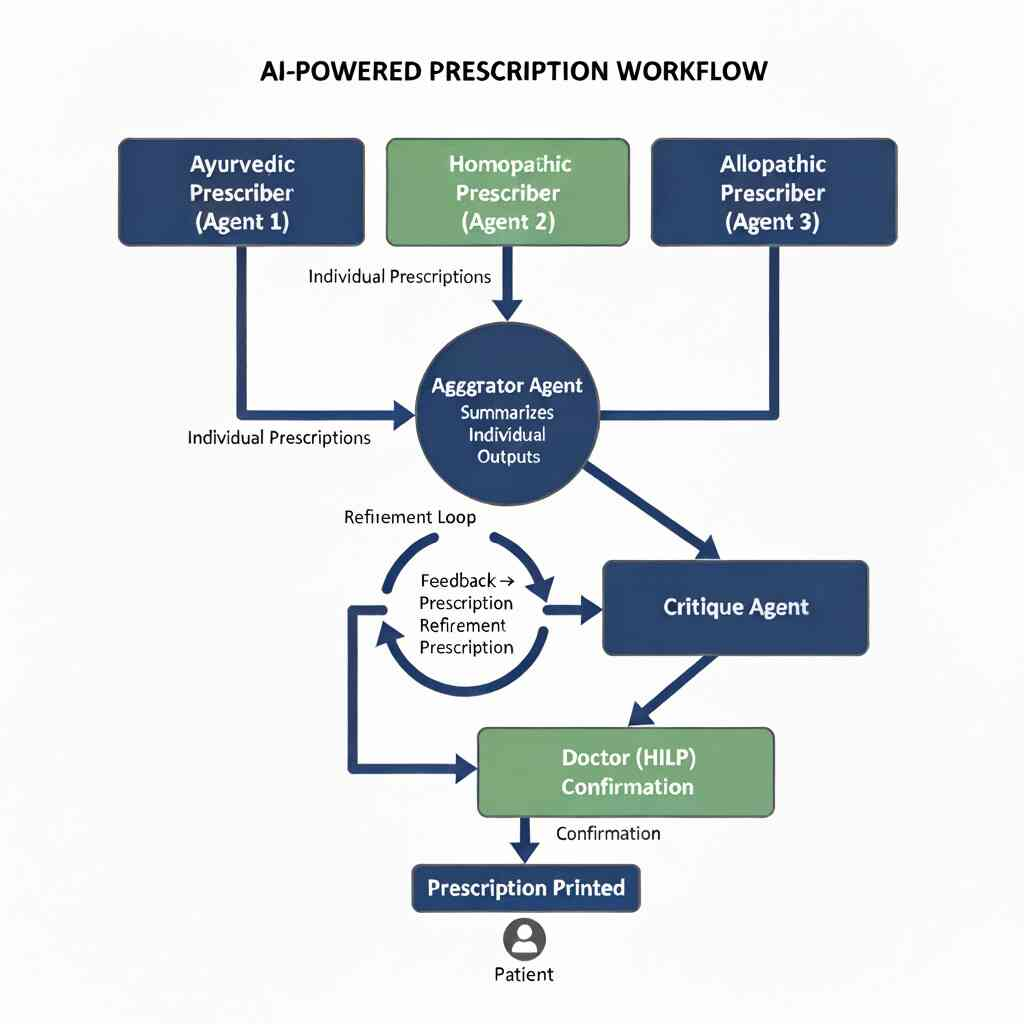

#### **Main Agents:**

**froot_agent(SequentialAgent)** - has the final prescription , runs shoot_agent and prescription_refinement_loop

**confirming_agent(LlmAgent)** - confirms prescription with doctor(has pausable tool)

#### Sub-Agents:

**Ayurvedic_agent** - prepares ayurvedic prescription

**Homeopathic_agent** - prepares homeopathic prescription

**Allopathic_agent** - prepares allopathic prescription

**Aggregator_agent** - combines all prescriptions

**parallel_research_team(ParallelAgent)** - runs all above three agents

**shoot_agent(SequentialAgent)** -runs parallel_research_team and then aggregator_agent

**critique_agent** - provide approval signal

**refiner_agent** - refine prescription based on critique or exit

**prescription_refinement_loop (LoopAgent)** -runs critique_agent and refiner_agent

#### Tools:
**google_search** - search grounding with google search

**function tool:exit_loop** - exits refinement loop

**function tool: place_prescription_order** - place order for approval by Doctor

#### Plugins:
**LoggingPlugin()** :Handles standard Observability logging across ALL agents

## Workflow:
### Stage 1:
Agent 1 : **ayurvedic_agent**

Agent 2 : **homeopathic_agent**

Agent 3 : **allopathic_agent**

these agents **work in parallel**

give indivisual outputs to **Aggregator Agent**

which in turn aggregates it and hands over to critique agent 

### Stage 2:
**Critique Agent** which is Looped in a **Refinement loop** where the prescription is finalized 

### Stage 3:
Prescription is presented to Doctor waiting for it's approval (**Human In the Loop** Workflow).

### Stage 4:
After it's approval by Doctor , **prescription is ready** and printed , ready to be given to patient.


## ⚙️ Section 1: Setup
### **Install dependencies**
The Kaggle Notebooks environment includes a pre-installed version of the google-adk library for Python and its required dependencies, so we don't need to install additional packages in this notebook.

In [2]:
#!pip install google-adk

###  1.1 Configure your Gemini API Key.
#### 1.This notebook uses the Gemini API, which requires authentication.

#### 2.Authenticate in the notebook.

Run the cell below to complete authentication.

In [3]:
import os
from kaggle_secrets import UserSecretsClient

try:
    GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
    os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "FALSE"
    print("✅ Gemini API key setup complete.")
except Exception as e:
    print(f"🔑 Authentication Error: Please make sure you have added 'GOOGLE_API_KEY' to your Kaggle secrets. Details: {e}")

✅ Gemini API key setup complete.


### 1.2 Import ADK components

Now, import the specific components we will need from the Agent Development Kit and the Generative AI library. This keeps our code organized and ensures we have access to the necessary building blocks.

In [4]:
import uuid
from google.genai import types

from google.adk.agents import Agent, SequentialAgent, ParallelAgent, LoopAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner
from google.adk.tools import AgentTool, FunctionTool, google_search
from google.genai import types

from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService

from google.adk.tools.mcp_tool.mcp_toolset import McpToolset
from google.adk.tools.tool_context import ToolContext
from google.adk.tools.mcp_tool.mcp_session_manager import StdioConnectionParams
from mcp import StdioServerParameters

from google.adk.apps.app import App, ResumabilityConfig
from google.adk.tools.function_tool import FunctionTool

print("✅ ADK components imported successfully.")

✅ ADK components imported successfully.


### 1.3 Helper functions

We'll define some helper functions. If you are running this outside the Kaggle environment, you don't need to do this.

In [5]:
# Define helper functions that will be reused throughout the notebook

from IPython.core.display import display, HTML
from jupyter_server.serverapp import list_running_servers

# Gets the proxied URL in the Kaggle Notebooks environment
def get_adk_proxy_url():
    PROXY_HOST = "https://kkb-production.jupyter-proxy.kaggle.net"
    ADK_PORT = "8000"

    servers = list(list_running_servers())
    if not servers:
        raise Exception("No running Jupyter servers found.")

    baseURL = servers[0]['base_url']

    try:
        path_parts = baseURL.split('/')
        kernel = path_parts[2]
        token = path_parts[3]
    except IndexError:
        raise Exception(f"Could not parse kernel/token from base URL: {baseURL}")

    url_prefix = f"/k/{kernel}/{token}/proxy/proxy/{ADK_PORT}"
    url = f"{PROXY_HOST}{url_prefix}"

    styled_html = f"""
    <div style="padding: 15px; border: 2px solid #f0ad4e; border-radius: 8px; background-color: #fef9f0; margin: 20px 0;">
        <div style="font-family: sans-serif; margin-bottom: 12px; color: #333; font-size: 1.1em;">
            <strong>⚠️ IMPORTANT: Action Required</strong>
        </div>
        <div style="font-family: sans-serif; margin-bottom: 15px; color: #333; line-height: 1.5;">
            The ADK web UI is <strong>not running yet</strong>. You must start it in the next cell.
            <ol style="margin-top: 10px; padding-left: 20px;">
                <li style="margin-bottom: 5px;"><strong>Run the next cell</strong> (the one with <code>!adk web ...</code>) to start the ADK web UI.</li>
                <li style="margin-bottom: 5px;">Wait for that cell to show it is "Running" (it will not "complete").</li>
                <li>Once it's running, <strong>return to this button</strong> and click it to open the UI.</li>
            </ol>
            <em style="font-size: 0.9em; color: #555;">(If you click the button before running the next cell, you will get a 500 error.)</em>
        </div>
        <a href='{url}' target='_blank' style="
            display: inline-block; background-color: #1a73e8; color: white; padding: 10px 20px;
            text-decoration: none; border-radius: 25px; font-family: sans-serif; font-weight: 500;
            box-shadow: 0 2px 5px rgba(0,0,0,0.2); transition: all 0.2s ease;">
            Open ADK Web UI (after running cell below) ↗
        </a>
    </div>
    """

    display(HTML(styled_html))

    return url_prefix

print("✅ Helper functions defined.")

✅ Helper functions defined.


### 1.4: Configure Retry Options

When working with LLMs, you may encounter transient errors like rate limits or temporary service unavailability. Retry options automatically handle these failures by retrying the request with exponential backoff.

In [6]:
retry_config=types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504], # Retry on these HTTP errors
)

## Scection 2 : Buiding Agents 
## Our Multi-Agent

**The Problem: The "Do-It-All" Agent**

Single agents can do a lot. But what happens when the task gets complex? A single "monolithic" agent that tries to write prescription for all [yypes of medicinal paradigms] and fact-checking all at once becomes a problem. Its instruction prompt gets long and confusing. It's hard to debug (which part failed?), difficult to maintain, and often produces unreliable results.

**The Solution: A Team of Specialists**

Instead of one "do-it-all" agent, we can build a multi-agent system. This is a team of simple, specialized agents that collaborate, just like a real-world team. Each agent has one clear job (e.g., one agent only does write prescription for homeopathy, another only for ayurved). This makes them easier to build, easier to test, and much more powerful and reliable when working together.

**Architecture: Single Agent vs Multi-Agent Team**

## 2.1 Prescription Writer System
Let's build a system with these specialized agents:

**Homeopathic Agent**- Suggest Homeopathic Medicines for the Disease.

**Ayurvedic Agent** - Suggest Ayurvedic Medicines for the Disease.

**Allopathic Agent** - Suggest Allopathic Medicines for the Disease.

**Critic Agent** - Checks the Authenticity , accuracy of the prescription.

**Human In the Loop** - Doctor approves the prescrption to be printed.

## 2.2 Define agents
Now, let's build our agent. We'll configure an Agent by setting its key properties, which tell it what to do and how to operate.

To learn more, check out the documentation related to agents in ADK.

These are the main properties we'll set:


* **name** and **description**: A simple name and description to identify our agent.
* **model**: The specific LLM that will power the agent's reasoning. We'll use "gemini-2.5-flash-lite".
* **instruction**: The agent's guiding prompt. This tells the agent its goal is and how to behave.
* **tools**: A list of tools that the agent can use. To start, we'll give it the google_search tool, which lets it find up-to-date information online.
  

## 2.3 Parallel Workflows - Independent Researchers

We have several tasks that are not dependent on each other.

The Solution: Concurrent Execution

When you have independent tasks, you can run them all at the same time using a ParallelAgent. This agent executes all of its sub-agents concurrently, dramatically speeding up the workflow. Once all parallel tasks are complete, you can then pass their combined results to a final 'aggregator' step.

Use Parallel when: Tasks are independent, speed matters, and you can execute concurrently

In [7]:
# Homeopathic Agent: Its job is to use the google_search tool and present medicines.
homeopathic_agent = Agent(
    name="HomeopathicAgent",
    model = Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # The instruction is modified to request medicines with proper dosage.
    instruction="""You are a specialized Homeopathic Doctor. Your only job is to use the
    google_search tool to find 2-3 relevant Homeopathic medicines with proper dosage for the given disease and present the medicines and dosage.""",
    tools=[google_search],
    output_key="homeopathic_findings", # The result of this agent will be stored in the session state with this key.
)

print("✅ homeopathic_agent created.")

✅ homeopathic_agent created.


In [8]:
# Ayurvedic Agent: Its job is to use the google_search tool and present medicines.
ayurvedic_agent = Agent(
    name="AyurvedicAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # The instruction is modified to request medicines with proper dosage.
    instruction="""You are a specialized Ayurvedic Doctor. Your only job is to use the
    google_search tool to find 2-3 relevant Ayurvedic medicines with proper dosage for the given disease and present the medicines and dosage.""",
    tools=[google_search],
    output_key="ayurvedic_findings",# The result of this agent will be stored in the session state with this key.
)

print("✅ ayurvedic_agent created.")

✅ ayurvedic_agent created.


In [9]:
# Allopathic Agent: Its job is to use the google_search tool and present medicines..
allopathic_agent = Agent(
    name="AllopathicAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # The instruction is modified to request medicines with proper dosage.
    instruction="""You are a specialized Allopathic Doctor. Your only job is to use the
    google_search tool to find 2-3 relevant Allopathic medicines with proper dosage for the given disease and present the medicines and dosage.""",
    tools=[google_search],
    output_key="allopathic_findings",# The result of this agent will be stored in the session state with this key.
)

print("✅ allopathic_agent created.")

✅ allopathic_agent created.


👉 Then we bring the agents together under a parallel agent, which is itself nested inside of a sequential agent.

This design ensures that the research agents run first in parallel, then once all of their research is complete, the aggregator agent brings together all of the research finding into a single prescription:

In [10]:
# The AggregatorAgent runs *after* the parallel step to synthesize the results.
aggregator_agent = Agent(
    name="AggregatorAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # It uses placeholders to inject the outputs from the parallel agents, which are now in the session state.
    instruction="""Combine these three medical prescriptions into a single executive prescription:

    **Homeopathic prescription:**
    {homeopathic_findings}
    
    **Ayurvedic prescription:**
    {ayurvedic_findings}
    
    **Allopathic prescription:**
    {allopathic_findings}
    
    Your prescription should contain only correct medicines with dosages for disease , and the tagline 'This is for informational purposes only. For medical advice or diagnosis, consult a professional. AI responses may include mistakes.'. The final prescription should be around 20 to 30 words.""",
    output_key="prescription_summary", # This will be the final output of the entire system.
)

print("✅ aggregator_agent created.")

✅ aggregator_agent created.


In [11]:
# The ParallelAgent runs all its sub-agents simultaneously.
parallel_research_team = ParallelAgent(
    name="ParallelResearchTeam",
    sub_agents=[ayurvedic_agent,homeopathic_agent,allopathic_agent],
)

# This SequentialAgent defines the high-level workflow: run the parallel team first, then run the aggregator.
shoot_agent = SequentialAgent(
    name="ResearchSystem",
    sub_agents=[parallel_research_team, aggregator_agent],
)

print("✅ Parallel and Sequential Agents created.")

✅ Parallel and Sequential Agents created.


## 2.4 Loop Workflows - The Refinement Cycle¶
ParallelAgent produce their final output and then stop. This 'one-shot' approach isn't good for tasks that require refinement and quality control. What if the first draft of our prescription is bad? We have no way to review it and ask for a rewrite.

The Solution: Iterative Refinement

When a task needs to be improved through cycles of feedback and revision, you can use a LoopAgent. A LoopAgent runs a set of sub-agents repeatedly until a specific condition is met or a maximum number of iterations is reached. This creates a refinement cycle, allowing the agent system to improve its own work over and over.

Use Loop when: Iterative improvement is needed, quality refinement matters, or you need repeated cycles.

In [12]:
# This agent's only job is to provide feedback or the approval signal. It has no tools.
critic_agent = Agent(
    name="CriticAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a Medical practitioner and Doctor critic. Review the medical prescription provided below.
    Prescription: {prescription_summary}

    Evaluate the prescription's medicines and it's dosage. 
    -The medicines prescribed should be highly accurate.
    -The prescription should have dosage for each medicine.
    -Citations to be included in prescription.
    If the prescription is well-written and complete, you MUST respond with the exact phrase: "APPROVED"
    - Otherwise, provide 2-3 specific, actionable suggestions for improvement.""",
    output_key="critique", # Stores the feedback in the state.
)

print("✅ critic_agent created.")

✅ critic_agent created.


## 2.5 Setup an Exit loop
Now, we need a way for the loop to actually stop based on the critic's feedback. The LoopAgent itself doesn't automatically know that "APPROVED" means "stop."

We need an agent to give it an explicit signal to terminate the loop.

We do this in two parts:


* A simple Python function that the LoopAgent understands as an "exit" signal.
* An agent that can call that function when the right condition is met.

First, we'll define the exit_loop function:

In [13]:
# This is the function that the RefinerAgent will call to exit the loop.
def exit_loop():
    """Call this function ONLY when the critique is 'APPROVED', indicating the prescription is finished and no more changes are needed."""
    return {"status": "approved", "message": "Prescription approved. Exiting refinement loop."}

print("✅ exit_loop function created.")

✅ exit_loop function created.


## 2.6 Define Refiner Agent
To let an agent call this Python function, we wrap it in a FunctionTool. Then, we create a RefinerAgent that has this tool.

👉 Notice its instructions: this agent is the "brain" of the loop. It reads the {critique} from the CriticAgent and decides whether to 
1. (1) **call the exit_loop tool**
   
                 or

2. (2) **rewrite the prescription.**

In [14]:
# This agent refines the prescrition based on critique OR calls the exit_loop function.
refiner_agent = Agent(
    name="RefinerAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a medical prescrition refiner. You have a prescription draft and critique.
    
    Prescription Draft: {prescription_summary}
    Critique: {critique}
    
    Your task is to analyze the critique.
    - IF the critique is EXACTLY "APPROVED", you MUST call the `exit_loop` function and nothing else.
    - OTHERWISE, rewrite the prescription draft to fully incorporate the feedback from the critique.""",
    
    output_key="prescription_summary", # It overwrites the story with the new, refined version.
    tools=[FunctionTool(exit_loop)], # The tool is now correctly initialized with the function reference.
)

print("✅ refiner_agent created.")

✅ refiner_agent created.


Then we bring the agents together under a loop agent, which is itself nested inside of a sequential agent.

This design ensures that the system first produces an initial story draft, then the refinement loop runs up to the specified number of max_iterations:

In [15]:
# The LoopAgent contains the agents that will run repeatedly: Critic -> Refiner.
prescription_refinement_loop = LoopAgent(
    name="PrescriptionRefinementLoop",
    sub_agents=[critic_agent, refiner_agent],
    max_iterations=2, # Prevents infinite loops
)

# The root agent is a SequentialAgent that defines the overall workflow: AggregatorAgent -> Refinement Loop.
froot_agent = SequentialAgent(
    name="PrescriptionPipeline",
    sub_agents=[shoot_agent , prescription_refinement_loop],
)

print("✅ Loop and Sequential Agents created.")

✅ Loop and Sequential Agents created.


## 3 Long-Running Operations (Human-in-the-Loop)¶
So far, all tools execute and return immediately:

User asks → Agent calls tool → Tool returns result → Agent responds

But what if your tools are long-running or you need human approval before completing an action?

Example: A shipping agent should ask for approval before placing a large order.

User asks → Agent calls tool → Tool PAUSES and asks human → Human approves → Tool completes → Agent responds

This is called a Long-Running Operation (LRO) - the tool needs to pause, wait for external input (human approval), then resume.

When to use Long-Running Operations:

💰 Financial transactions requiring approval (transfers, purchases)

🗑️ Bulk operations (delete 1000 records - confirm first!)

📋 Compliance checkpoints (regulatory approval needed)

💸 High-cost actions (spin up 50 servers - are you sure?)

⚠️ Irreversible operations (permanently delete account)

## What We're Building Today
Let's build a prescription coordinator agent with one tool that:

Pauses and asks for approval on prescription orders 
Completes or cancels based on the approval decision
This demonstrates the core long-running operation pattern: pause → wait for human input → resume.

## 3.1 The Prescription Tool with Approval Logic
Here's the complete function.

The ToolContext Parameter
Notice the function signature includes tool_context: ToolContext. ADK automatically provides this object when your tool runs. It gives you two key capabilities:

Request approval: Call **tool_context.request_confirmation()**
Check approval status: Read tool_context.tool_confirmation

In [16]:
def place_prescription_order(
   number : int, quality : str, tool_context: ToolContext
) -> dict:
    """Places a prescription order. Requires approval by a Doctor.

    Args:
        quality : Whether approved by Doctor or not

    Returns:
        Dictionary with prescription status
    """

    # -----------------------------------------------------------------------------------------------
    # SCENARIO 1 : This is the time this tool is called. Large orders need human approval - PAUSE here.
    if not tool_context.tool_confirmation:
        tool_context.request_confirmation(
            hint=f"⚠️ Prescrition : {number} . Do you want to approve?",
        )
        return {  # This is sent to the Agent
            "status": "pending",
            "message": f"This prescription requires approval",
        }

    # -----------------------------------------------------------------------------------------------
    # SCENARIO 2: The tool is called AGAIN and is now resuming. Handle approval response - RESUME here.
    if tool_context.tool_confirmation.confirmed:
        return {
            "status": "approved",
            "order_id": f"ORD-{number}-HUMAN",
            "quality": quality ,
            "message": f"Prescription approved",
        }
    else:
        return {
            "status": "rejected",
            "message": f"Prescription rejected",
        }


print("✅ Long-running functions created!")

✅ Long-running functions created!


How the Three Scenarios Work
The tool handles two scenarios by checking tool_context.tool_confirmation:

### Scenario 1: Prescription order - FIRST CALL

Tool detects it's a first call: if not tool_context.tool_confirmation:
Calls request_confirmation() to request human approval
Returns {'status': 'pending', ...} immediately
ADK automatically creates adk_request_confirmation event
Agent execution pauses - waiting for human decision

### Scenario 2: Prescription check - RESUMED CALL

Tool detects it's resuming: if not tool_context.tool_confirmation: is now False
Checks human decision: tool_context.tool_confirmation.confirmed
If True → Returns approved status
If False → Returns rejected status

Key insight: Between the two calls, your workflow code must detect the adk_request_confirmation event and resume with the approval decision

In [17]:
# Create confirming agent with pausable tool
confirming_agent = LlmAgent(
    name="confirming_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    instruction="""You are a Compounder , Doctors' coordinator assistant.
  
  When Doctor request to prescription:
   1. Use the place_prescription_order tool with the status of prescription 
   2. If the order status is 'pending', inform the user that approval is required
   3. After receiving the final result, provide a clear summary including:
      - Order status (approved/rejected)
      - Order ID (if available)
   4. Keep responses concise but informative
  """,
    tools=[FunctionTool(func=place_prescription_order)],
)

print("✅ Confirming Agent created!")

✅ Confirming Agent created!


## 3.2 Wrap in resumable App

The problem: A regular LlmAgent is stateless - each call is independent with no memory of previous interactions. If a tool requests approval, the agent can't remember what it was doing.

The solution: Wrap your agent in an App with resumability enabled. The App adds a persistence layer that saves and restores state.

What gets saved when a tool pauses:

All conversation messages so far
Which tool was called (place_prescription_order)
Tool parameters (5, NotApproved)
Where exactly it paused (waiting for approval)
When you resume, the App loads this saved state so the agent continues exactly where it left off - as if no time passed.

In [18]:
# Wrap the agent in a resumable app - THIS IS THE KEY FOR LONG-RUNNING OPERATIONS!
prescription_app = App(
    name="prescription_coordinator",
    root_agent=confirming_agent,
    resumability_config=ResumabilityConfig(is_resumable=True),
)

print("✅ Resumable app created!")

✅ Resumable app created!


/tmp/ipykernel_13/1223343667.py:5: UserWarning: [EXPERIMENTAL] ResumabilityConfig: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  resumability_config=ResumabilityConfig(is_resumable=True),


## 3.3 Create Session and Runner with the App

Pass app=prescription_app instead of agent=... so the runner knows about resumability.

In [19]:
session_service = InMemorySessionService()

# Create runner with the resumable app
prescription_runner = Runner(
    app=prescription_app,  # Pass the app instead of the agent
    session_service=session_service,
)

print("✅ Runner created!")

✅ Runner created!


## 4 Building the Workflow¶
‼️ Important: The workflow code uses ADK concepts like Sessions, Runners, and Events. We'll cover what you need to know for long-running operations in this notebook.

⚠️ The Critical Part - Handling Events in Your Workflow
The agent won't automatically handle pause/resume. Every long-running operation workflow requires you to:

Detect the pause: Check if events contain adk_request_confirmation
Get human decision: In production, show UI and wait for user click. Here, we simulate it.
Resume the agent: Send the decision back with the saved invocation_id

Understand Key Technical Concepts
👉 events - ADK creates events as the agent executes. Tool calls, model responses, function results - all become events

👉 adk_request_confirmation event - This event is special - it signals "pause here!"

Automatically created by ADK when your tool calls **request_confirmation()**
Contains the invocation_id
Your workflow must detect this event to know the agent paused
👉 invocation_id - Every call to **run_async()** gets a unique invocation_id (like "abc123")

When a tool pauses, you save this ID
When resuming, pass the same ID so ADK knows which execution to continue
Without it, ADK would start a NEW execution instead of resuming the paused one

Helper Functions to Process Events

These handle the event iteration logic for you.

**check_for_approval()** - Detects if the agent paused

Loops through all events and looks for the special adk_request_confirmation event
Returns approval_id (identifies this specific request) and invocation_id (identifies which execution to resume)
Returns None if no pause detected

## 4.2 Helper Functions to Process Events
These handle the event iteration logic for us.

**check_for_approval()** - Detects if the agent paused

Loops through all events and looks for the special adk_request_confirmation event
Returns approval_id (identifies this specific request) and invocation_id (identifies which execution to resume)
Returns None if no pause detected

In [20]:
def check_for_approval(events):
    """Check if events contain an approval request.

    Returns:
        dict with approval details or None
    """
    for event in events:
        if event.content and event.content.parts:
            for part in event.content.parts:
                if (
                    part.function_call
                    and part.function_call.name == "adk_request_confirmation"
                ):
                    return {
                        "approval_id": part.function_call.id,
                        "invocation_id": event.invocation_id,
                    }
    return None

**print_agent_response()** - Displays agent text

* Simple helper to extract and print text from events

In [21]:
def print_agent_response(events):
    """Print agent's text responses from events."""
    for event in events:
        if event.content and event.content.parts:
            for part in event.content.parts:
                if part.text:
                    print(f"Agent > {part.text}")

**create_approval_response()** - Formats the human decision


* Takes the approval info and boolean decision (True/False) from the human
* Creates a FunctionResponse that ADK understands
* Wraps it in a Content object to send back to the agent


In [22]:
def create_approval_response(approval_info, approved):
    """Create approval response message."""
    confirmation_response = types.FunctionResponse(
        id=approval_info["approval_id"],
        name="adk_request_confirmation",
        response={"confirmed": approved},
    )
    return types.Content(
        role="user", parts=[types.Part(function_response=confirmation_response)]
    )


print("✅ Helper functions defined")

✅ Helper functions defined


## 4.3 The Workflow Function - Let's tie it all together!
The **run_prescription_workflow()** function orchestrates the entire approval flow.

Look for the code explanation in the cell below.

In [23]:
async def run_prescription_workflow(query: str, auto_approve: bool = True):
    """Runs  prescription workflow  with approval handling.

    Args:
        query: User's prescription request
        auto_approve: Whether to auto-approve large orders (simulates human decision)
    """

    print(f"\n{'='*60}")
    print(f"User > {query}\n")

    # Generate unique session ID
    session_id = f"order_{uuid.uuid4().hex[:8]}"

    # Create session
    await session_service.create_session(
        app_name="prescription_coordinator", user_id="test_user", session_id=session_id
    )

    query_content = types.Content(role="user", parts=[types.Part(text=query)])
    events = []

    # -----------------------------------------------------------------------------------------------
    # -----------------------------------------------------------------------------------------------
    # STEP 1: Send initial request to the Agent. If num_containers > 5, the Agent returns the special `adk_request_confirmation` event
    async for event in prescription_runner.run_async(
        user_id="test_user", session_id=session_id, new_message=query_content
    ):
        events.append(event)

    # -----------------------------------------------------------------------------------------------
    # -----------------------------------------------------------------------------------------------
    # STEP 2: Loop through all the events generated and check if `adk_request_confirmation` is present.
    approval_info = check_for_approval(events)

    # -----------------------------------------------------------------------------------------------
    # -----------------------------------------------------------------------------------------------
    # STEP 3: If the event is present, it's a large order - HANDLE APPROVAL WORKFLOW
    if approval_info:
        print(f"⏸️  Pausing for approval...")
        print(f"🤔 Human Decision: {'APPROVE ✅' if auto_approve else 'REJECT ❌'}\n")

        # PATH A: Resume the agent by calling run_async() again with the approval decision
        async for event in prescription_runner.run_async(
            user_id="test_user",
            session_id=session_id,
            new_message=create_approval_response(
                approval_info, auto_approve
            ),  # Send human decision here
            invocation_id=approval_info[
                "invocation_id"
            ],  # Critical: same invocation_id tells ADK to RESUME
        ):
            if event.content and event.content.parts:
                for part in event.content.parts:
                    if part.text:
                        print(f"Agent > {part.text}")

    # -----------------------------------------------------------------------------------------------
    # -----------------------------------------------------------------------------------------------
    else:
        # PATH B: If the `adk_request_confirmation` is not present - no approval needed - order completed immediately.
        print_agent_response(events)

    print(f"{'='*60}\n")


print("✅ Workflow function ready")

✅ Workflow function ready


Code breakdown

**Step 1: Send initial request to the Agent**

* Call **run_async()** to start agent execution
* Collect all events in a list for inspection
* 
**Step 2: Detect Pause**

* Call **check_for_approval(events)** to look for the special event: adk_request_confirmation
* Returns approval info (with invocation_id) if the special event is present; None if completed

**Step 3: Resume execution**

PATH A:

* If the approval info is present, at this point the Agent pauses for human input.
* Once the Human input is available, call the agent again using **run_async()** and pass in the Human input.
* Critical: Same invocation_id (tells ADK to RESUME, not restart)
* Display agent's final response after resuming

**PATH B:**

* If the approval info is not present, then approval is not needed and the agent completes execution.

In [24]:
from google.adk.runners import InMemoryRunner

# Initialize the runner and keep it in memory
#prescription_runner = InMemoryRunner(agent=root_agent)
#print("✅ Runner is initialized and ready.")

## 4.4 Demo: Testing the Workflow
Now, let's run our demos. Notice how much cleaner and easier to read they are. All the complex logic for pausing and resuming is now hidden away in our run_workflow helper function, allowing us to focus on the tasks we want the agent to perform.

Note: You may see warnings like Warning: there are non-text parts in the response: ['function_call'] - this is normal and can be ignored. It just means the agent is calling tools in addition to generating text.

In [25]:
# Demo : Workflow simulates human decision: APPROVE ✅
await run_prescription_workflow("Prepare prescription 1 , approved", auto_approve=True)


User > Prepare prescription 1 , approved



/usr/local/lib/python3.11/dist-packages/google/adk/tools/tool_context.py:92: UserWarning: [EXPERIMENTAL] ToolConfirmation: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  ToolConfirmation(
/usr/local/lib/python3.11/dist-packages/google/adk/agents/invocation_context.py:298: UserWarning: [EXPERIMENTAL] BaseAgentState: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self.agent_states[event.author] = BaseAgentState()


⏸️  Pausing for approval...
🤔 Human Decision: APPROVE ✅




##  4.5 Run your agent
Now it's time to bring your agent to life and send it a query. To do this, you need a Runner, which is the central component within ADK that acts as the orchestrator. It manages the conversation, sends our messages to the agent, and handles its responses.

**a. Create an InMemoryRunner and tell it to use our root_agent:**

In [26]:
runner = InMemoryRunner(agent=froot_agent)

print("✅ Runner created.")

✅ Runner created.


## 4.6 Add LoggingPlugin to Runner
The following code creates the InMemoryRunner. This is used to programmatically invoke the agent.

To use LoggingPlugin in the above research agent, 1) Import the plugin 2) Add it when initializing the InMemoryRunner.

### ADK's built-in LoggingPlugin
But you don't have to define all the callbacks and plugins to capture standard Observability data in ADK. Instead, ADK provides a built-in LoggingPlugin that automatically captures all agent activity:

🚀 User messages and agent responses

⏱️ Timing data for performance analysis

🧠 LLM requests and responses for debugging

🔧 Tool calls and results

✅ Complete execution traces

In [27]:
from google.adk.runners import InMemoryRunner
from google.adk.plugins.logging_plugin import (
    LoggingPlugin,
)  # <---- 1. Import the Plugin
from google.genai import types
import asyncio

runner = InMemoryRunner(
    agent=froot_agent,
    plugins=[
        LoggingPlugin()
    ],  # <---- 2. Add the plugin. Handles standard Observability logging across ALL agents
)

print("✅ Runner configured")

✅ Runner configured


b. Now you can call the **.run_debug()** method to send our prompt and get an answer.

👉 This method abstracts the process of session creation and maintenance and is used in prototyping.

In [28]:
response = await runner.run_debug("Medicines for Throat inflamation")


 ### Created new session: debug_session_id

User > Medicines for Throat inflamation
[logging_plugin] 🚀 USER MESSAGE RECEIVED
[logging_plugin]    Invocation ID: e-ab824189-4ad9-4ecc-9ace-e9718ce7363b
[logging_plugin]    Session ID: debug_session_id
[logging_plugin]    User ID: debug_user_id
[logging_plugin]    App Name: InMemoryRunner
[logging_plugin]    Root Agent: PrescriptionPipeline
[logging_plugin]    User Content: text: 'Medicines for Throat inflamation'
[logging_plugin] 🏃 INVOCATION STARTING
[logging_plugin]    Invocation ID: e-ab824189-4ad9-4ecc-9ace-e9718ce7363b
[logging_plugin]    Starting Agent: PrescriptionPipeline
[logging_plugin] 🤖 AGENT STARTING
[logging_plugin]    Agent Name: PrescriptionPipeline
[logging_plugin]    Invocation ID: e-ab824189-4ad9-4ecc-9ace-e9718ce7363b
[logging_plugin] 🤖 AGENT STARTING
[logging_plugin]    Agent Name: ResearchSystem
[logging_plugin]    Invocation ID: e-ab824189-4ad9-4ecc-9ace-e9718ce7363b
[logging_plugin] 🤖 AGENT STARTING
[logging_plugin

[logging_plugin] 🧠 LLM RESPONSE
[logging_plugin]    Agent: RefinerAgent
[logging_plugin]    Content: text: 'The critique accurately identifies the shortcomings of the initial prescription draft. To address these points, I will rewrite the prescription to include specific dosages for allopathic and Ayurvedic...' | function_call: exit_loop
[logging_plugin]    Token Usage - Input: 2863, Output: 1263
[logging_plugin] 📢 EVENT YIELDED
[logging_plugin]    Event ID: 9b91237a-5f09-4d98-b77a-810af0767659
[logging_plugin]    Author: RefinerAgent
[logging_plugin]    Content: text: 'The critique accurately identifies the shortcomings of the initial prescription draft. To address these points, I will rewrite the prescription to include specific dosages for allopathic and Ayurvedic...' | function_call: exit_loop
[logging_plugin]    Final Response: False
[logging_plugin]    Function Calls: ['exit_loop']
RefinerAgent > The critique accurately identifies the shortcomings of the initial prescription draf

[logging_plugin] 🧠 LLM RESPONSE
[logging_plugin]    Agent: RefinerAgent
[logging_plugin]    Content: function_call: exit_loop
[logging_plugin]    Token Usage - Input: 3739, Output: 10
[logging_plugin] 📢 EVENT YIELDED
[logging_plugin]    Event ID: f13b34a4-9f9c-44b7-ab0c-0d444a3063f0
[logging_plugin]    Author: RefinerAgent
[logging_plugin]    Content: function_call: exit_loop
[logging_plugin]    Final Response: False
[logging_plugin]    Function Calls: ['exit_loop']
[logging_plugin] 🔧 TOOL STARTING
[logging_plugin]    Tool Name: exit_loop
[logging_plugin]    Agent: RefinerAgent
[logging_plugin]    Function Call ID: adk-594fd0fc-c7d0-45fc-a1e9-2229dea58701
[logging_plugin]    Arguments: {}
[logging_plugin] 🔧 TOOL COMPLETED
[logging_plugin]    Tool Name: exit_loop
[logging_plugin]    Agent: RefinerAgent
[logging_plugin]    Function Call ID: adk-594fd0fc-c7d0-45fc-a1e9-2229dea58701
[logging_plugin]    Result: {'status': 'approved', 'message': 'Prescription approved. Exiting refinement loo

## 5 Get Prescription Printed

In [29]:
import re
from IPython.display import HTML, Markdown, display

text_parts = []

# 1. Extract text from response (Standard loop)
for item in response:
    if isinstance(item, str):
        text_parts.append(item)
    elif hasattr(item, "content") and item.content:
        if hasattr(item.content, "parts") and item.content.parts:
            for part in item.content.parts:
                if part.text:
                    text_parts.append(part.text)

full_response_text = "".join(text_parts)

clean_pattern = r"(\s*APPROVED\s*)+$"

# Remove ALL trailing "APPROVED" instances found by the pattern
full_response_text = re.sub(clean_pattern, "", full_response_text, flags=re.IGNORECASE)

# 3. Add the single, final signature
full_response_text = full_response_text.strip() + "\n\n**APPROVED**"

# 4. Display
display(Markdown(full_response_text))

For throat inflammation, several Allopathic medications can be used depending on the severity and cause of the inflammation. Here are a few options:

**Over-the-Counter (OTC) Medications:**

*   **Acetaminophen (Tylenol):** Effective for mild to moderate pain relief. The typical dosage for adults is 325 mg to 1000 mg every 4 to 6 hours as needed, not exceeding 4000 mg in 24 hours.
*   **Ibuprofen (Advil, Motrin):** Reduces pain and inflammation. For adults, a common dosage is 200 mg to 400 mg every 4 to 6 hours as needed.
*   **Naproxen (Aleve):** Also an NSAID that reduces pain and inflammation. For adults, the typical dosage is 220 mg to 550 mg every 8 to 12 hours.
*   **Throat Sprays and Lozenges:** These often contain numbing agents like benzocaine or menthol for temporary relief. Follow the product's specific instructions for use, as frequency can vary.

**Prescription Medications:**

*   **Corticosteroids (e.g., Dexamethasone):** These are potent anti-inflammatory medications. For adults, a single oral dose of 10 mg of dexamethasone is often prescribed. For children aged 5-18, the dose is typically 0.6 mg/kg, with a maximum of 10 mg. These are usually reserved for more severe cases or when significant inflammation is present.
*   **Antibiotics (e.g., Penicillin, Amoxicillin):** These are prescribed only if the throat inflammation is due to a bacterial infection, such as strep throat.
    *   **Penicillin:** Adults: 250 mg four times daily or 500 mg twice daily for 10 days. Children: 250 mg two or three times daily for 10 days (dose adjusted by weight).
    *   **Amoxicillin:** Adults: 500 mg twice daily or 250 mg three times daily for 10 days. Children: 50 mg/kg once daily (maximum 1000 mg) or 25 mg/kg twice daily for 10 days.

It is important to consult with a healthcare professional for an accurate diagnosis and the most appropriate treatment plan for your specific condition. Self-medication can be dangerous, and antibiotics should only be used when prescribed by a doctor.For throat inflammation, Ayurveda offers several effective remedies that balance doshas and reduce discomfort. Here are a few options:

*   **Turmeric Milk (Haldi Doodh):** Turmeric is well-known for its anti-inflammatory and antimicrobial properties.
    *   **Dosage:** Mix 1/2 teaspoon of turmeric powder into a cup of warm milk. A pinch of black pepper can be added to enhance curcumin absorption.

*   **Ginger and Honey Mixture:** Ginger's warming and anti-inflammatory properties, combined with honey's soothing and natural cough-suppressing qualities, make this a potent remedy.
    *   **Dosage:** Mix 1 teaspoon of fresh ginger juice with 1 teaspoon of honey. Consume this mixture 2-3 times a day.

*   **Licorice Root (Mulethi/Yashtimadhu):** Licorice root has sweet, cooling, and healing properties that help reduce throat irritation and inflammation by forming a protective layer.
    *   **Dosage:** 1 teaspoon of Yashtimadhu powder mixed with warm water or honey, twice daily.

*   **Tulsi (Holy Basil) Tea:** Tulsi possesses antibacterial, antiviral, and anti-inflammatory properties, making it excellent for boosting immunity and soothing the throat.
    *   **Dosage:** Boil 8-10 fresh tulsi leaves in 1.5 cups of water for 5-7 minutes. Strain and sip warm.

*   **Gargling with Turmeric and Salt Water:** This traditional remedy helps reduce swelling, clear mucus, and fight infection.
    *   **Dosage:** Dissolve 1/2 teaspoon of turmeric powder and a pinch of salt in a glass of warm water. Gargle for 30 seconds, 2-3 times a day.

*   **Sitopaladi Churna:** This formulation balances Kapha and Vata doshas and acts as an expectorant.
    *   **Dosage:** 1-2 grams with honey, 2-3 times a day.

*   **Talisadi Churna:** This potent formulation helps alleviate throat irritation by reducing Kapha and clearing mucus.
    *   **Dosage:** 1-2 grams with honey or warm water after meals.

*   **Khadiradi Vati:** Known for its antibacterial and anti-inflammatory properties, it soothes irritation and reduces swelling.
    *   **Dosage:** 1-2 tablets to be sucked slowly, 3-4 times a day.

Always consult with an Ayurvedic practitioner for personalized advice and dosage, especially if you have pre-existing medical conditions or are on medication.For throat inflammation, several homeopathic medicines can be considered based on specific symptoms. Here are a few commonly recommended options with their typical dosages:

*   **Belladonna**: This is often indicated for sudden, intense sore throats that are accompanied by redness and swelling. The throat may feel throbbing, and swallowing can cause sharp pains.
    *   **Dosage**: For acute symptoms, 30C potency can be taken every 2-4 hours.

*   **Hepar Sulphuris Calcareum (Hepar Sulph)**: This remedy is useful when there's a sensation of a splinter or fishbone in the throat, especially when swallowing. It's also considered if symptoms worsen with cold air or cold drinks, and are better with warmth.
    *   **Dosage**: A common dosage is 30C potency, taken every 4-6 hours.

*   **Mercurius Solubilis (Merc Sol)**: This remedy is indicated for sore throats with a burning and raw sensation, increased salivation, and potentially swollen tonsils. There might also be an offensive taste or breath.
    *   **Dosage**: Typically prescribed in a 30C potency, taken every 4-6 hours.

*   **Arnica Montana**: This remedy is often used for sore throats resulting from injury or overexertion of the vocal cords, leading to hoarseness.
    *   **Dosage**: Arnica Montana 200CH has been used, with doses taken over a period of time, for example, three doses over 36 hours.

*   **ThroatCalm Tablets**: This is a commercially available homeopathic preparation that combines several remedies. It is designed to relieve occasional minor sore throat pain and hoarseness.
    *   **Dosage**: For adults and children 6 years and older, dissolve 2 tablets under the tongue every 15 minutes for the first hour, then 2 tablets every 6 hours. For children 4 to under 6 years, dissolve 2 tablets in 1 tablespoon of water and follow the adult dosage.

It is important to consult with a qualified homeopath or healthcare professional to determine the most suitable remedy and potency based on your individual symptoms.**Throat Inflammation Prescription:**

*   **Allopathic:** Acetaminophen/Ibuprofen (as needed), Dexamethasone (severe cases), or Antibiotics (if bacterial).
*   **Ayurvedic:** Turmeric milk, Ginger-honey, Licorice root, or Khadiradi Vati.
*   **Homeopathic:** Belladonna, Hepar Sulph, Merc Sol, Arnica, or ThroatCalm.

This is for informational purposes only. For medical advice or diagnosis, consult a professional. AI responses may include mistakes.CriticAgent: The provided prescription is a compilation of suggestions from different medical approaches and lacks the specificity required for a medical document.

Here are the areas for improvement:

1.  **Missing Dosages for Allopathic and Ayurvedic Medicines:** The prescription lists "Acetaminophen/Ibuprofen (as needed)" and "Dexamethasone (severe cases)" under Allopathic, and "Turmeric milk, Ginger-honey, Licorice root, or Khadiradi Vati" under Ayurvedic. While the individual agents provided some dosage information, the aggregated prescription does not specify any dosages for these medications or remedies. This makes it incomplete and potentially unsafe for self-administration.
2.  **Lack of Specificity for Antibiotics and "if bacterial":** The mention of "Antibiotics (if bacterial)" is too vague. A proper prescription requires the specific antibiotic, its strength (e.g., amoxicillin 500mg), and the frequency and duration of treatment. The condition "if bacterial" also implies a diagnosis is needed, which is beyond the scope of a general prescription.
3.  **Incomplete Homeopathic Dosing:** While the Homeopathic agent provided some dosage examples, the aggregated prescription simply lists the names of the remedies without any dosage information. For homeopathic remedies, potency and frequency are crucial for therapeutic effectiveness.
4.  **Absence of Citations/References:** The prescription lacks any citations or references to support the listed treatments, which is a standard requirement for medical documentation.
5.  **No Indication of Severity or Patient Profile:** The prescription does not specify the patient's age, weight, severity of symptoms, or any pre-existing conditions, all of which are critical for determining appropriate medication and dosage. For instance, Dexamethasone is for "severe cases," but what constitutes "severe" is not defined.

In summary, this prescription is a collection of potential treatments rather than a actionable medical order. It requires detailed dosages, specific drug names (where applicable), and consideration of patient-specific factors to be considered complete or well-written.The critique accurately identifies the shortcomings of the initial prescription draft. To address these points, I will rewrite the prescription to include specific dosages for allopathic and Ayurvedic medicines, provide more detail on antibiotic usage (while still emphasizing the need for a diagnosis), include homeopathic potencies and frequencies, and add a disclaimer regarding patient-specific factors.

Here is the revised prescription:

**Revised Throat Inflammation Prescription:**

**Important Disclaimer:** This prescription is for informational purposes only and is a compilation of potential treatments. It is NOT a substitute for professional medical advice, diagnosis, or treatment. Dosages and treatments must be determined by a qualified healthcare professional based on an individual's specific condition, age, weight, severity of symptoms, and medical history. Self-medication can be dangerous.

**I. Allopathic Treatments (Consult a Healthcare Professional for Specifics):**

*   **Pain and Inflammation Management (Mild to Moderate Cases):**
    *   **Acetaminophen:** Adults: 325 mg to 1000 mg every 4-6 hours as needed (max 4000 mg/day).
    *   **Ibuprofen:** Adults: 200 mg to 400 mg every 4-6 hours as needed.
    *   **Naproxen:** Adults: 220 mg to 550 mg every 8-12 hours as needed.
    *   *Note: Specific dosage for children depends on age and weight.*
*   **Severe Inflammation:**
    *   **Dexamethasone:** Typically prescribed for severe cases. For adults, a single oral dose of 10 mg may be used. For children aged 5-18, the dose is typically 0.6 mg/kg, with a maximum of 10 mg. *Requires a prescription and medical supervision.*
*   **Bacterial Infections (Only if Diagnosed by a Healthcare Professional):**
    *   **Antibiotics:** Prescribed ONLY if a bacterial infection (e.g., Strep Throat) is confirmed.
        *   **Amoxicillin:** Adults: 500 mg twice daily for 10 days, OR 250 mg three times daily for 10 days. Children: Dose based on weight (e.g., 50 mg/kg once daily, max 1000 mg, for 10 days).
        *   **Penicillin V:** Adults: 250 mg four times daily for 10 days, OR 500 mg twice daily for 10 days. Children: Dose based on weight (e.g., 250 mg two or three times daily for 10 days).
    *   *Note: The specific antibiotic, strength, and duration of treatment will be determined by the diagnosing physician.*

**II. Ayurvedic Treatments (Consult an Ayurvedic Practitioner for Personalization):**

*   **For Mild Sore Throat & Cough:**
    *   **Turmeric Milk:** Mix 1/2 teaspoon of turmeric powder with a pinch of black pepper into a cup of warm milk. Consume once daily.
    *   **Ginger-Honey Mixture:** Mix 1 teaspoon of fresh ginger juice with 1 teaspoon of honey. Consume 2-3 times a day.
    *   **Licorice Root (Mulethi/Yashtimadhu):** 1 teaspoon of powder mixed with warm water or honey, taken twice daily.
*   **For Congestion & Inflammation:**
    *   **Gargling with Turmeric and Salt Water:** Dissolve 1/2 teaspoon of turmeric powder and a pinch of salt in a glass of warm water. Gargle for 30 seconds, 2-3 times a day.
*   **Herbal Formulations (Consult Practitioner for Specific Use):**
    *   **Khadiradi Vati:** 1-2 tablets to be sucked slowly, 3-4 times a day.
    *   **Sitopaladi Churna:** 1-2 grams with honey, 2-3 times a day.
    *   **Talisadi Churna:** 1-2 grams with honey or warm water after meals.

**III. Homeopathic Treatments (Consult a Qualified Homeopath for Potency and Frequency):**

*   **For Sudden, Intense Sore Throat with Redness:**
    *   **Belladonna:** 30C potency, taken every 2-4 hours during acute symptoms.
*   **For Sore Throat with Splinter Sensation, Worse from Cold:**
    *   **Hepar Sulphuris Calcareum (Hepar Sulph):** 30C potency, taken every 4-6 hours.
*   **For Sore Throat with Burning, Rawness, Offensive Breath:**
    *   **Mercurius Solubilis (Merc Sol):** 30C potency, taken every 4-6 hours.
*   **For Sore Throat due to Injury or Vocal Strain:**
    *   **Arnica Montana:** 200CH potency, e.g., three doses over 36 hours.
*   **Combination Remedy for Occasional Minor Sore Throat:**
    *   **ThroatCalm Tablets:** Adults/Children 6+: Dissolve 2 tablets under the tongue every 15 mins for 1st hour, then every 6 hours. Children 4-6: Dissolve 2 tablets in 1 tbsp water, follow adult dosage.

**General Advice:**

*   **Hydration:** Drink plenty of fluids.
*   **Rest:** Ensure adequate rest.
*   **Avoid Irritants:** Stay away from smoke, allergens, and dry air.

**Reminder:** The effectiveness and safety of any treatment depend on individual patient factors. Always consult with a healthcare professional before starting any new treatment, especially if you have underlying health conditions, are pregnant or breastfeeding, or are taking other medications.

**APPROVED**